In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100

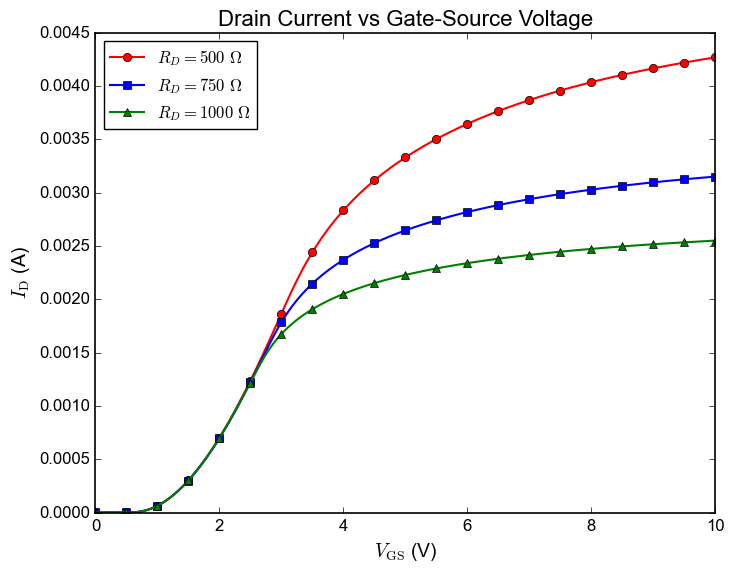

In [35]:
data1 = np.loadtxt("./Data-Amplify/20260405001.dat")
data2 = np.loadtxt("./Data-Amplify/20260405002.dat")
data3 = np.loadtxt("./Data-Amplify/20260405003.dat")

datasets = [
    (r'$R_D = 500 ~\Omega$', 500, data1, 'red', 'o'),
    (r'$R_D = 750 ~\Omega$', 750, data2, 'blue', 's'),
    (r'$R_D = 1000 ~\Omega$', 1000, data3, 'green', '^'),
]
for label, R_D, data, color, marker in datasets:
    V_GS = data[:, 0]
    I_D = data[:, 1]
    V_DS = data[:, 2]
    V_out = V_DS - I_D * R_D
    V_in = V_GS
    A = np.diff(V_out) / np.diff(V_in)
    V_in_A = (V_in[:-1] + V_in[1:]) / 2
    plt.plot(V_in, I_D, lw=1.5, marker=marker, linestyle='-', color=color, label=label, markersize=6, markevery=10)

plt.xlabel(r'$V_\text{GS}$ (V)', fontsize=14)
plt.ylabel(r'$I_\text{D}$ (A)', fontsize=14)
plt.xlim(0, 10)
plt.title('Drain Current vs Gate-Source Voltage', fontsize=16)
plt.legend(frameon=True, loc='upper left', fontsize=12, numpoints=1)
plt.show()



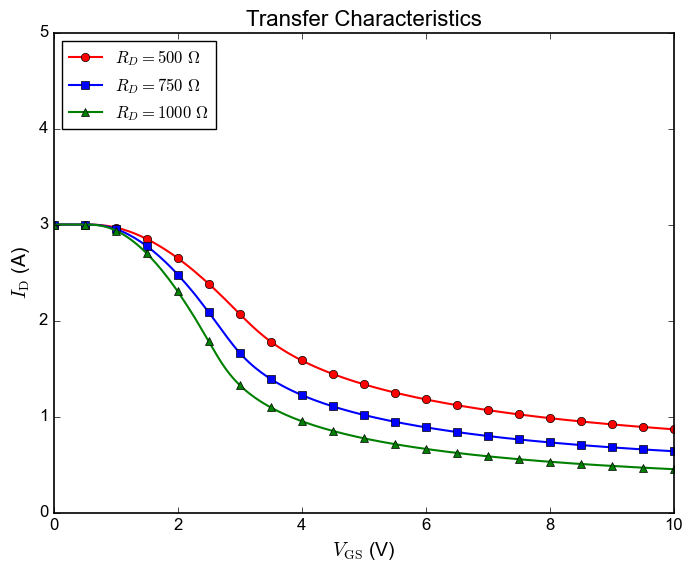

In [36]:
for label, R_D, data, color, marker in datasets:
    V_GS = data[:, 0]
    I_D = data[:, 1]
    V_DS = data[:, 2]
    V_out = V_DS - I_D * R_D
    V_in = V_GS
    A = np.diff(V_out) / np.diff(V_in)
    V_in_A = (V_in[:-1] + V_in[1:]) / 2
    plt.plot(V_in, V_out, lw=1.5, marker=marker, linestyle='-', color=color, label=label, markersize=6, markevery=10)
plt.xlabel(r'$V_\text{GS}$ (V)', fontsize=14)
plt.ylabel(r'$I_\text{D}$ (A)', fontsize=14)
plt.xlim(0, 10)
plt.ylim(0, 5)
plt.title('Transfer Characteristics', fontsize=16)
plt.legend(frameon=True, loc='upper left', fontsize=12, numpoints=1)
plt.show()


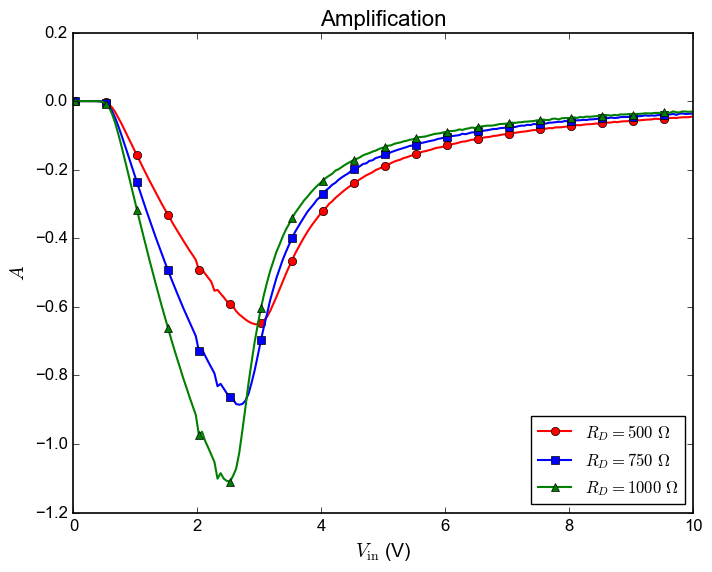

In [37]:
for label, R_D, data, color, marker in datasets:
    V_GS = data[:, 0]
    I_D = data[:, 1]
    V_DS = data[:, 2]
    V_out = V_DS - I_D * R_D
    V_in = V_GS
    A = np.diff(V_out) / np.diff(V_in)
    V_in_A = (V_in[:-1] + V_in[1:]) / 2
    plt.plot(V_in_A, A, lw=1.5, marker=marker, linestyle='-', color=color, label=label, markersize=6, markevery=10)
plt.xlabel(r'$V_\text{in}$ (V)', fontsize=14)
plt.ylabel(r'$A$', fontsize=14)
plt.xlim(0, 10)
plt.title('Amplification', fontsize=16)
plt.legend(frameon=True, loc='lower right', fontsize=12, numpoints=1)
plt.show()

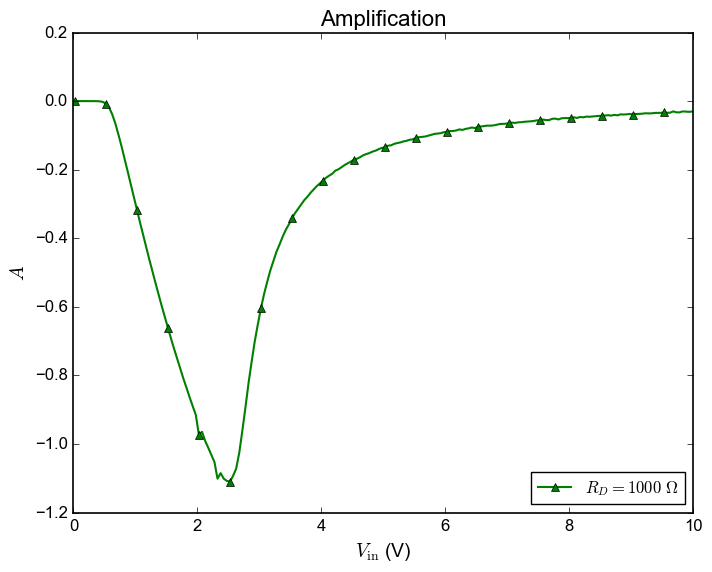

In [38]:
V_GS = data3[:, 0]
I_D = data3[:, 1]
V_DS = data3[:, 2]
V_out = V_DS - I_D * R_D
V_in = V_GS
A = np.diff(V_out) / np.diff(V_in)
V_in_A = (V_in[:-1] + V_in[1:]) / 2
plt.plot(V_in_A, A, lw=1.5, marker=marker, linestyle='-', color=color, label=label, markersize=6, markevery=10)
plt.xlabel(r'$V_\text{in}$ (V)', fontsize=14)
plt.ylabel(r'$A$', fontsize=14)
plt.xlim(0, 10)
plt.title('Amplification', fontsize=16)
plt.legend(frameon=True, loc='lower right', fontsize=12, numpoints=1)
plt.show()

R^2 = 0.996674
Fitted parameters: a = -0.6540, b = 0.3494
Alpha = 0.0007


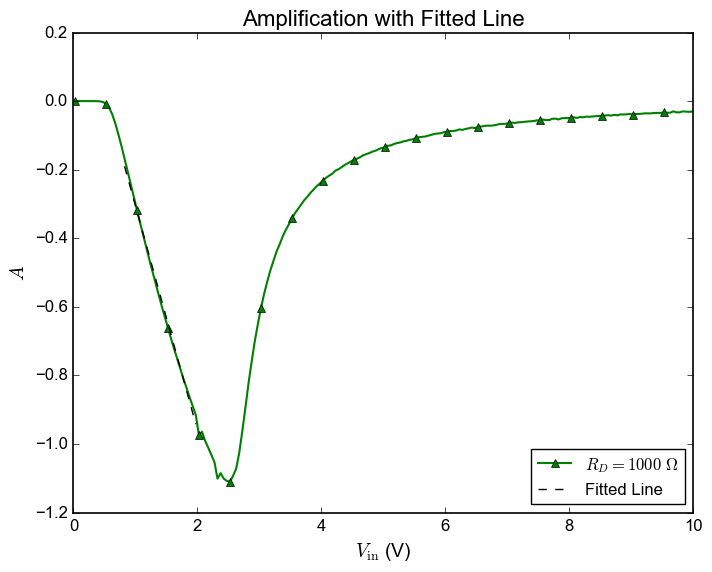

In [39]:
from scipy.optimize import curve_fit

def func(x,a,b):
    return a*x+b


R_D = 1000
mask = (V_in_A > 0.8) & (V_in_A < 2)

popt, pcov = curve_fit(func, V_in_A[mask], A[mask])
a, b = popt
a_err, b_err = np.sqrt(np.diag(pcov))
x_fit = V_in_A[mask]
y_data = A[mask]
y_model = func(x_fit, *popt)
residuals = y_data - y_model
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
print(f"R^2 = {r2:.6f}")
print(f"Fitted parameters: a = {a:.4f}, b = {b:.4f}")
print(f"Alpha = {-a/R_D:.4f}")

plt.plot(V_in_A, A, lw=1.5, marker=marker, linestyle='-', color=color, label=label, markersize=6, markevery=10)
plt.plot(V_in_A[mask], func(V_in_A[mask], *popt), 'k--', label='Fitted Line')
plt.xlabel(r'$V_\text{in}$ (V)', fontsize=14)
plt.ylabel(r'$A$', fontsize=14)
plt.xlim(0, 10)
plt.title('Amplification with Fitted Line', fontsize=16)
plt.legend(frameon=True, loc='lower right', fontsize=12, numpoints=1)
plt.show()



In [40]:
print(np.sqrt(2*0.0007*1000*3 + 1) - 1)

1.2803508501982757
